# OH Analysis
## Preamble

In [2]:
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from chempiler import ChempilerTrajectory, plot_rdf, diffusive_window
from chempiler.state_engine import atom_hop, ligand_exchange

import tol_colors as tc
cset = tc.bright

plt.rcParams.update({
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.prop_cycle': plt.cycler(color=cset)
})

dt = 0.5 # fs
dump_interval = 10

LOGFILE     = '../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH.log'
CALCFILE     = '../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH_calc.h5'
TRAJFILE    = '../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH.traj'

In [3]:
print('Reading OH• trajectory...')
traj = ChempilerTrajectory(
    TRAJFILE,
    mode='molecular', covalent_scale=0.8, # NOTE: The small covalent scale is important to capture the O-H bond in the ion. To avoid seeing clusters of water molecules as bonded.
)
print('Building topology...')
traj.build(
    cache_file='tests/OH_rad_new_cache.h5',
    companion=CALCFILE,
    persistence=3,
)
print('Done.')
print('Molecular species in trajectory:')
traj.summary()

Reading OH• trajectory...
Building topology...
[Chempiler] loaded cache → tests/OH_rad_new_cache.h5
[Chempiler] persistence=3: corrected 1 frames
[Chempiler] companion attached → ../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH_calc.h5 (20001 frames, 14 properties: charges, density_coefficients, dipole, electron_energy, electrostatic_energy, energies, energy, forces, free_energy, interaction_energy, node_energy, spin_charge_density, spins, stress)
Done.
Molecular species in trajectory:


{'H2O': 780033, 'HO': 20001, 'H4O2': 3}

## Summary of molecules

,n_segs,coverage,min,median,mean,max
formula,,,,,,
H2O,1,100.0%,20001,20001,20001.0,20001
HO,1,100.0%,20001,20001,20001.0,20001
H4O2,2,0.0%,1,2,2.0,3


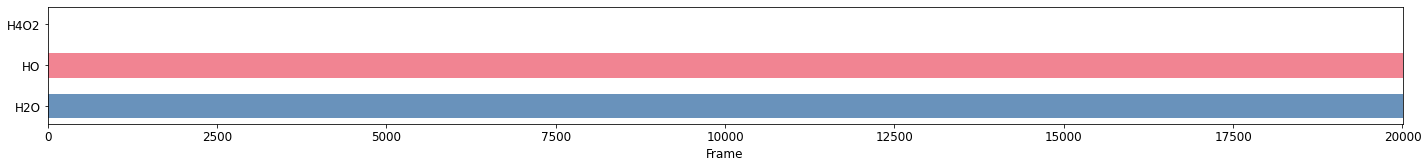

In [19]:
# Dataframe
rows = []
for formula, _ in traj.summary().items():
    segs = traj.lifetime_segments(formula)
    lengths = np.array([e - s for s, e in segs])
    covered = lengths.sum()
    rows.append({
        'formula':  formula,
        'n_segs':   len(segs),
        'coverage': f"{100 * covered / len(traj.frames):.1f}%",
        'min':      int(lengths.min()),
        'median':   int(np.median(lengths)),
        'mean':     f"{lengths.mean():.1f}",
        'max':      int(lengths.max()),
    })

species = sorted(traj.summary().keys(), key=lambda f: -traj.summary()[f])
fig, ax = plt.subplots(figsize=(20, 0.5 * len(species) + 1))

for i, (row_colour, formula) in enumerate( zip(cset, species) ):
    for s, e in traj.lifetime_segments(formula):
        ax.barh(i, e - s, left=s, height=0.6, color=row_colour, alpha=0.8)

ax.set_yticks(range(len(species)))
ax.set_yticklabels(species)
ax.set_xlabel('Frame')
ax.set_xlim(0, len(traj.frames))
plt.tight_layout()

pd.DataFrame(rows).set_index('formula')


In [20]:
#from ase.io import read, write
#atoms = read(TRAJFILE, '::2')
#write(TRAJFILE, atoms)

In [21]:
#print(atoms)
#print(atoms.arrays.keys())
#print(atoms.info.keys())
#print(atoms.calc.results.keys())
#print(atoms.calc.results['spin_charge_density'])

In [22]:

#traj = ChempilerTrajectory('run.traj')
#traj.build(companion='run_polar.h5')
# frame.atoms.arrays now has: charges, spins, node_energy, density_coefficients, …
# frame.atoms.info now has:   dipole, interaction_energy, electron_energy, …

# Count-based SDF (positions)
#hists, meta = spatial_density_maps(traj.frames, center=..., target=..., symmetry='Cinfv')

# Spin-density SDF (spin accumulated at each position)
#hists_spin, meta = spatial_density_maps(traj.frames, center=..., target=...,
#                                         symmetry='Cinfv', weights='spins')


In [4]:
from chempiler import spatial_density_maps, plot_sdf_panel

targets = {
    'O$_h \\cdots$O$_w$': {"H2O": "O"},
    'O$_h \\cdots$H$_w$': {"H2O": "H"},
}

panels = {
    label: spatial_density_maps(
        traj.frames,
        center={"HO": "O"},
        align_to={"HO": "H"},
        target=pair,
        symmetry='Cinfv',
        rmax=5.0, bins=100, stride=1,
    )
    for label, pair in targets.items()
}

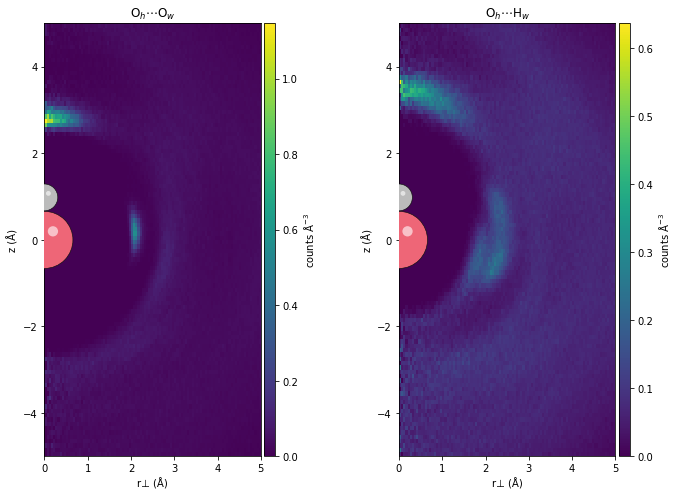

In [6]:
fig, axs = plt.subplots(1, len(panels), figsize=(5 * len(panels), 7))

for ax, (label, data) in zip(axs, panels.items()):
    ax.plot_sdf(
        data,
        projection='cylindrical',
        center_symbol='O',
        align_symbol='H',
        normalize='density',
        cmap='viridis',
    )
    ax.set_title(label)

plt.tight_layout()

In [ ]:
from chempiler import spatial_density_maps, plot_sdf


full_spin_panel = spatial_density_maps(
    traj.frames,
    center={"HO": "H"},
    align_to={"HO": "O"},
    target=None,
    exclude_align=False,
    symmetry='Cinfv',
    #weights='spins',
    weights=lambda frame: (
        frame.atoms.arrays['spin_charge_density'][:, 0, 0]-frame.atoms.arrays['spin_charge_density'][:, 1, 0]
    ),
    rmax=5.0, bins=100, stride=1,
)

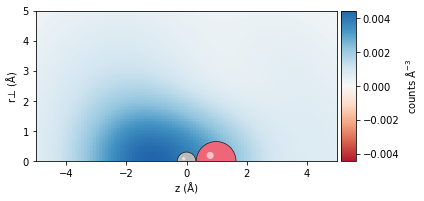

In [ ]:
from chempiler import spatial_density_maps, gto_kernel


k = gto_kernel(
    alphas=[0.222],
    coeffs=[1.0],
)

fig, ax = plt.subplots()
ax.plot_sdf(
    full_spin_panel,
    projection='cylindrical',
    center_symbol='H',
    align_symbol='O',
    normalize='density',
    symmetric=True,
    cmap='BuRd_r',
    smooth_extent=4*1.5,
    #vmax=0.005,
    #render='contour',
    smooth_kernel=k,
    #smooth_extent=1,

)
plt.tight_layout()

In [4]:
from chempiler import spatial_density_maps, plot_sdf_maps, gto_kernel

k = gto_kernel(
    alphas=[0.222],
    coeffs=[1.0],
)


full_spin_panel = spatial_density_maps(
    traj.frames,
    center={"H2O": "O"},
    align_to={"H2O": "H"},
    target={"HO": "O"},
    exclude_align=False,
    symmetry='C2v',
    weights=lambda frame: (
        frame.atoms.arrays['spin_charge_density'][:, 0, 0]-frame.atoms.arrays['spin_charge_density'][:, 1, 0]
    ),
    rmax=5.0, bins=100, stride=1,
)

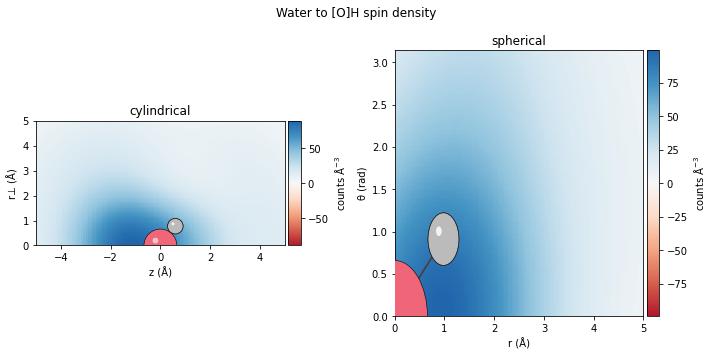

In [28]:
fig, axs = plot_sdf_maps(
    full_spin_panel,
    center_symbol='O',
    align_symbol='H',
    secondary_symbol='H',
    angle_deg=104.5,
    bisector=True,
    normalize='density',
    symmetric=True,
    cmap='BuRd_r',
    #vmax=0.06,
    smooth_extent=4*1.5,
    #flip_bond=True,
    #render='contour',
    smooth_kernel=k,
)
fig.suptitle('Water to [O]H spin density')
fig.tight_layout()